In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *
from SliceTCA_example import *


GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]


fixed_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_factors_dict_NDNF_newest[f"animal_{idx+1}"] = factors_dict_NDNF_newest[animal]


/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
from comparing_slice_TCA_methods import *

In [3]:
data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_residual_activity_dict_NDNF_newest)

data_truncated_array_NDNF.shape


(115, 50, 100)

In [4]:

def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_truncated_array_EC, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:data_truncated_array_EC.shape[2]]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:data_truncated_array_EC.shape[2]]
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


r_dict_vel = get_r_list(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Velocity")
r_dict_licks = get_r_list(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Licks")
            

r_dict_vel_resid = get_r_list(fixed_residual_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Velocity")
r_dict_licks_resid = get_r_list(fixed_residual_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Licks")

In [10]:
save_path="/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl"

with open (save_path, 'rb') as f:
    model_and_mse_dict_NDNF = pickle.load(f)
    print(save_path)

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl


In [11]:
model_20_NDNF_raw_0x0 = model_and_mse_dict_NDNF[20]['model']

KeyError: 20

In [7]:
# labels_cells_dict_all_K_EC_x00_raw = get_labels_all_different_Ks_single(model_20_EC_raw_x00, which_vectors=0)
labels_cells_dict_all_K_NDNF_0x0_raw = get_labels_all_different_Ks_single(model_20_NDNF_raw_0x0, which_vectors=1)
# labels_cells_dict_all_K_EC_00x_raw = get_labels_all_different_Ks_single(model_20_EC_raw_00x, which_vectors=2)

# labels_cells_dict_all_K_EC_x00_resid = get_labels_all_different_Ks_single(model_20_EC_resid_x00, which_vectors=0)
# labels_cells_dict_all_K_EC_0x0_resid = get_labels_all_different_Ks_single(model_20_EC_resid_0x0, which_vectors=1)
# labels_cells_dict_all_K_EC_00x_resid = get_labels_all_different_Ks_single(model_20_EC_resid_00x, which_vectors=2)

F.shape (20, 100, 50)  W.shape (20, 115)
X shape (mean over pos): (115, 20)


/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


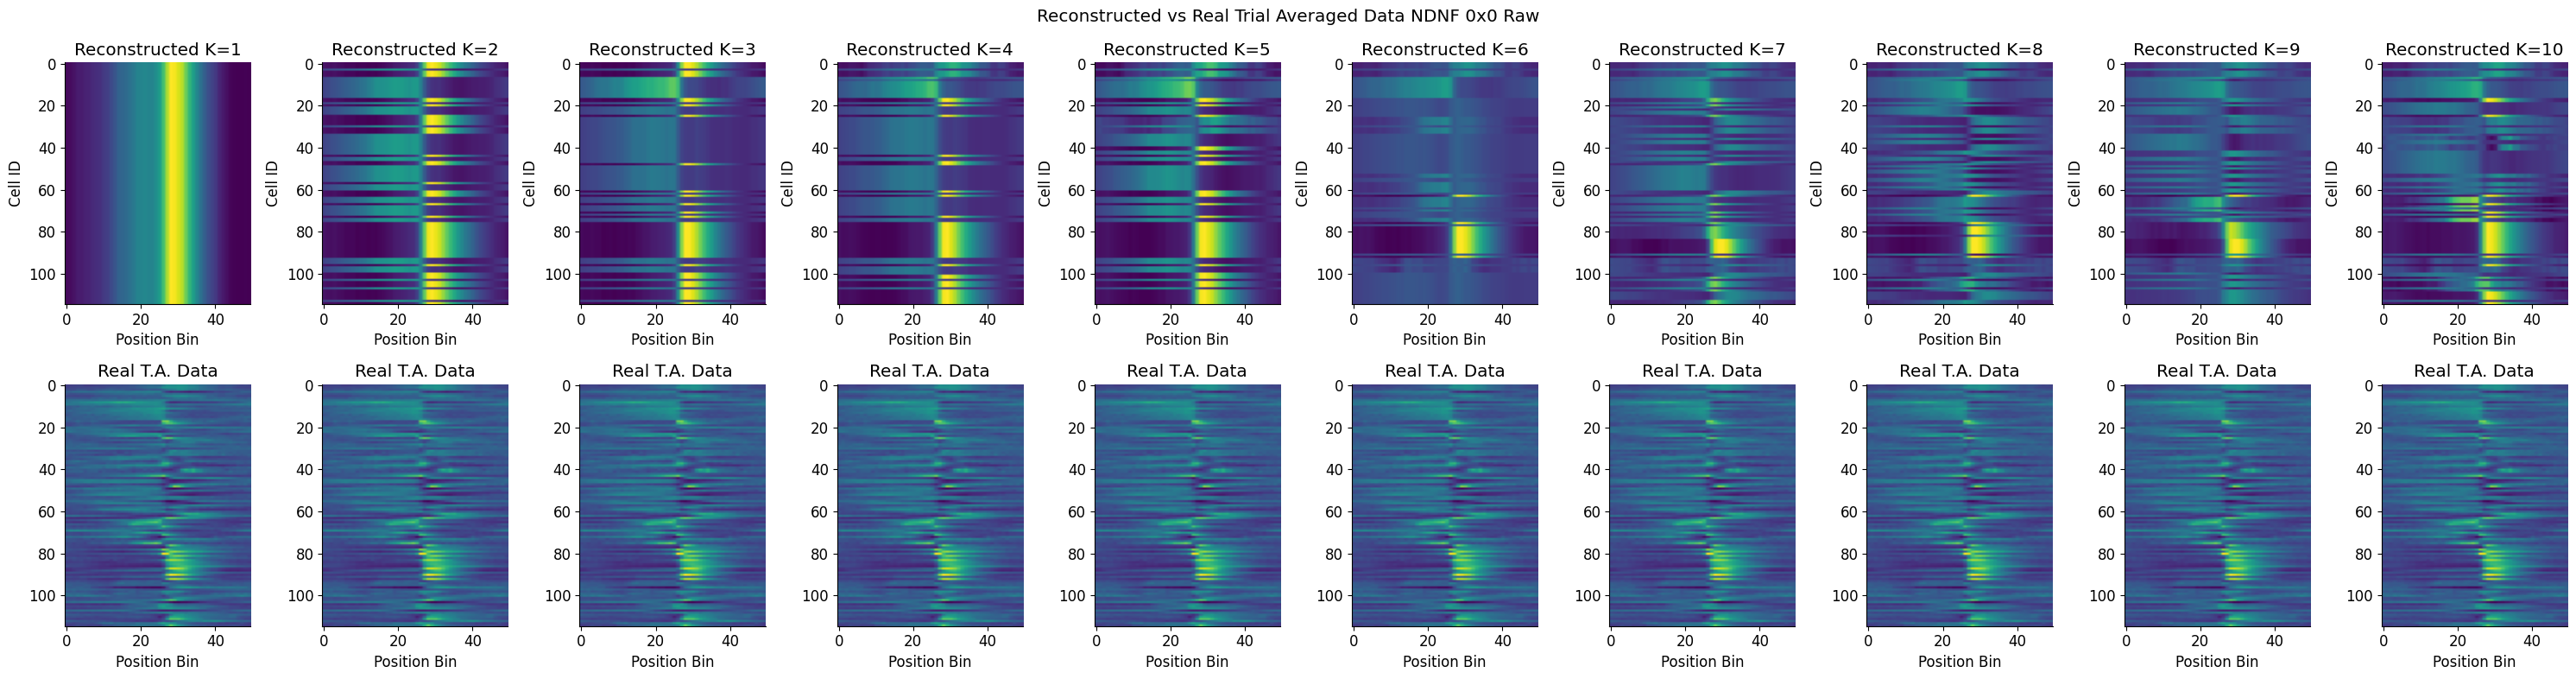

In [8]:
means_dict_cluster_0x0_raw = plot_reconstructions(labels_cells_dict_all_K_NDNF_0x0_raw, fixed_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF 0x0 Raw")


F.shape (20, 100, 50)  W.shape (20, 115)
X shape (mean over pos): (115, 20)


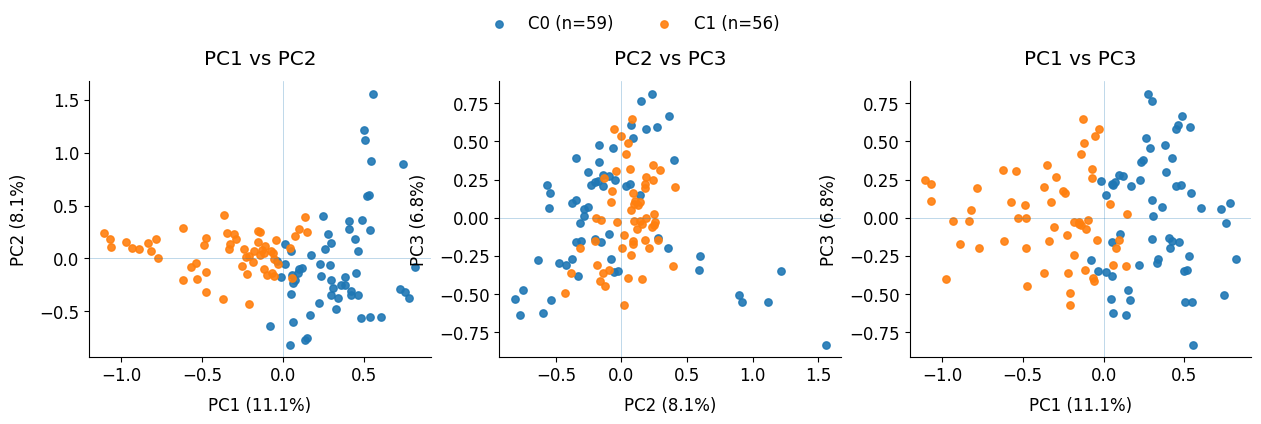

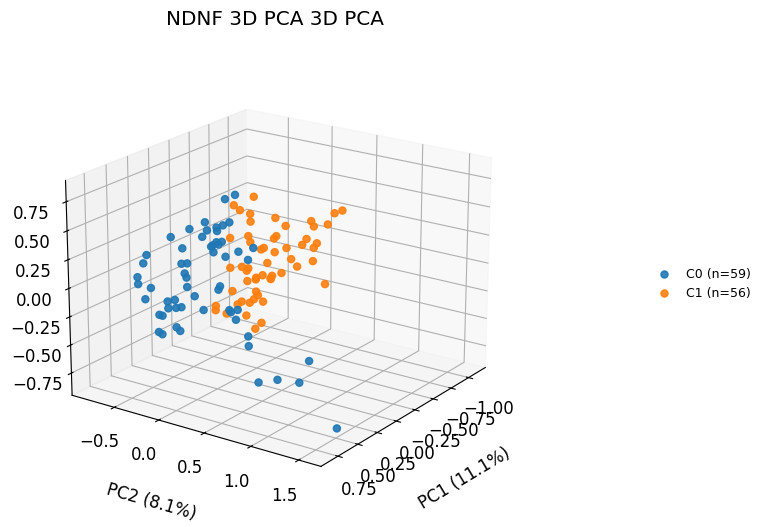

/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


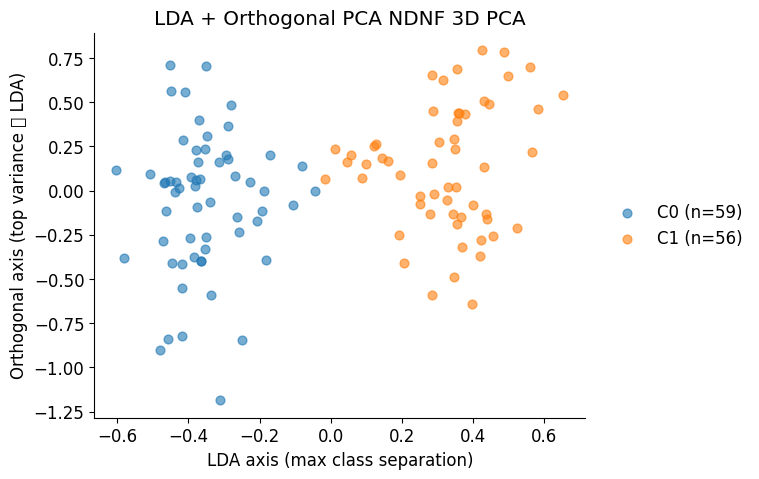

/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


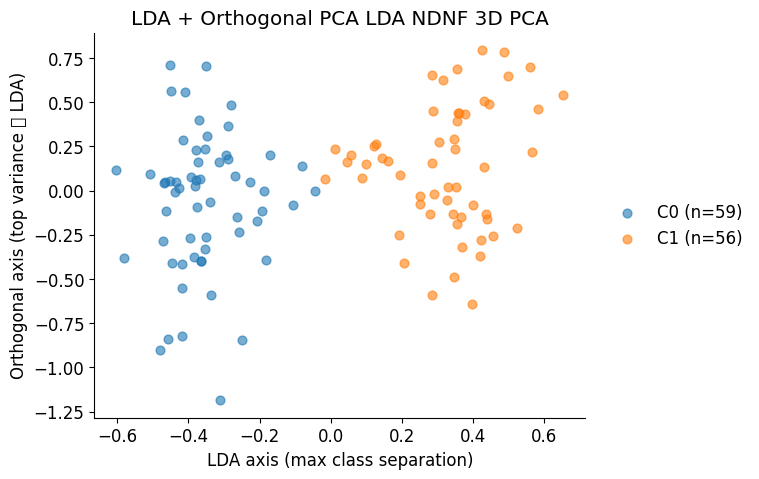

In [9]:
out = pca_cluster_viz(
    model_20_NDNF_raw_0x0,
    which_vectors=1,
    feature_space="loadings",     # or whatever you’re using in get_cell_features
    feature_mode="0x0",     # your existing arg
    n_cells_expected=115,         # fill with your expected count
    n_latents_expected=20,       # fill with your expected count
    n_components=3,
    num_clusters=2,               # <= set 2 if you want the LDA+orth trick; ≥3 uses LDA(2)
    title_prefix="NDNF 3D PCA")
